Task 1: Data Preprocessing

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Step 1. importing CSV file for analysis
my_dataset = pd.read_csv('Housing.csv')

# Step 2. Look for missing values
print("Missing values before cleaning:\n", my_dataset.isnull().sum())

# Step 3. Handle Categorical Data (Turning 'yes/no' into 1/0)
# This is called Label Encoding
le = LabelEncoder()
categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
for col in categorical_cols:
    my_dataset[col] = le.fit_transform(df[col])

# Step 4. Select the Feature
# 'price' is what we want to predict (Target). The rest are Features.
X = my_dataset.drop('price', axis=1)
y = my_dataset['price']

# Step 5. Scaling
# Machine learning models perform better when numbers are on a similar scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 6. Split data into 2 parts (80% for training & 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("\nPreprocessed Data Sample:\n", pd.DataFrame(X_train).head())

Missing values before cleaning:
 price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Preprocessed Data Sample:
          0         1         2         3         4         5         6   \
0  0.391790  0.047278  1.421812  2.532024  0.405623 -0.465315 -0.734539   
1  0.945257  0.047278  1.421812 -0.929397  0.405623 -0.465315  1.361397   
2 -0.615521 -1.308863 -0.570187 -0.929397  0.405623 -0.465315  1.361397   
3 -1.171756  0.047278 -0.570187  0.224410  0.405623 -0.465315  1.361397   
4 -0.645962  0.047278 -0.570187  0.224410  0.405623 -0.465315 -0.734539   

         7         8         9         10        11  
0 -0.219265  1.472618  0.355976 -0.554035 -1.406286  
1 -0.219265  1.472618  2.679409 -0.554035 -0.091662  
2 -0.219265  1.472618  1.51

Task 2: Simple Linear Regression

Mean Squared Error: 1771751116594.04
R-squared Score (Accuracy): 0.6494754192267793


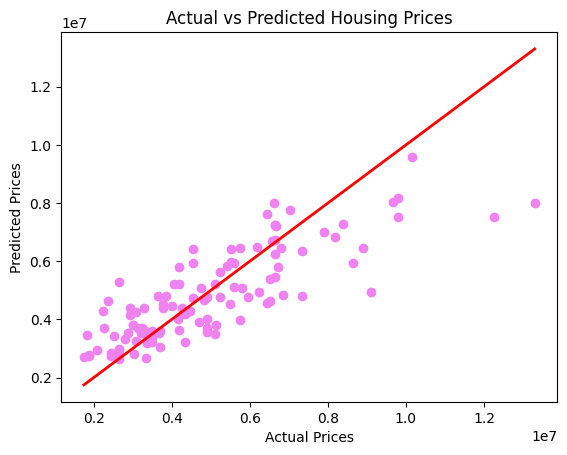

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Step 1. Creating and Training the Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Step 2. Making Predictions
y_pred = lr_model.predict(X_test)

# Step 3. Evaluating the Results
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared Score (Accuracy): {r2}")

# Step 4. Visualizing the Prediction
plt.scatter(y_test, y_pred, color='violet')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Housing Prices")
plt.show()